# Fine-tune ConvNeXt v2 (Notebook 3)

โน้ตบุ๊กนี้ครอบคลุมการเตรียมข้อมูล, preprocessing, การปรับแต่งโมเดล, การบันทึกโมเดล, การประเมินผล และตัวอย่างการใช้งาน inference

ขั้นตอนหลัก:
1. โหลดและสำรวจชุดข้อมูล
2. สร้าง preprocessing pipeline และ DataLoader
3. โหลดโมเดล ConvNeXt v2 และจัดการ label mapping
4. ฝึกโมเดลและติดตามผล
5. บันทึกโมเดลและเตรียมชุดทดสอบ
6. ประเมินผลด้วยชุดทดสอบ
7. ตัวอย่างการใช้งาน inference


In [76]:
from datasets import load_dataset

In [77]:
dataset = load_dataset("imagefolder", data_dir="/kaggle/input/wdafewfa/final_dataset_split")

Resolving data files:   0%|          | 0/569 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/162 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/83 [00:00<?, ?it/s]

## 1. โหลดและสำรวจข้อมูล

โหลด dataset จาก directory structure แบบ `imagefolder` แล้วตรวจสอบ metadata เพื่อให้แน่ใจว่า class labels ถูกต้อง


In [78]:
dataset["train"].features

{'image': Image(mode=None, decode=True, id=None),
 'label': ClassLabel(names=['100%', '60%', '80%'], id=None)}

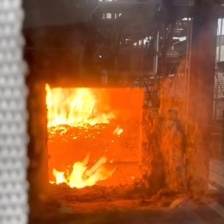

In [79]:
example = dataset["train"][80]
example["image"]

In [80]:
labels = dataset["train"].features["label"].names
print(labels)

['100%', '60%', '80%']


In [81]:
id2label = {k:v for k,v in enumerate(labels)}
label2id = {v:k for k,v in enumerate(labels)}
print(id2label)

{0: '100%', 1: '60%', 2: '80%'}


In [82]:
from transformers import AutoImageProcessor

## 2. สร้าง pipeline preprocessing และ DataLoader

กำหนดการแปลงภาพเข้าโมเดลด้วย `torchvision.transforms` และเตรียม `DataLoader` สำหรับใช้งานในการฝึกสอน


In [83]:
image_processor = AutoImageProcessor.from_pretrained("facebook/convnextv2-tiny-1k-224") 

In [84]:
from torchvision.transforms import (
    Compose,
    Normalize,
    RandomHorizontalFlip,
    RandomResizedCrop,
    ToTensor,
)

normalize = Normalize(mean=image_processor.image_mean, std=image_processor.image_std)

transform = Compose(
    [
     RandomResizedCrop(image_processor.size["shortest_edge"]),
     RandomHorizontalFlip(),
     ToTensor(),
     normalize
    ]
)

def train_transforms(examples):
  examples["pixel_values"] = [transform(image.convert("RGB")) for image in examples["image"]]

  return examples

In [85]:
processed_dataset = dataset.with_transform(train_transforms)

In [86]:
processed_dataset["train"][0].keys()

dict_keys(['image', 'label', 'pixel_values'])

In [87]:
import torch
from torch.utils.data import DataLoader

def collate_fn(examples):
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

dataloader = DataLoader(processed_dataset["train"], collate_fn=collate_fn, batch_size=4, shuffle=True)

In [88]:
batch = next(iter(dataloader))
for k,v in batch.items():
  print(k,v.shape)

pixel_values torch.Size([4, 3, 224, 224])
labels torch.Size([4])


## 3. โหลดโมเดลและจัดการ label mapping

สร้าง mapping ระหว่าง labels และ indices แล้วโหลดโมเดล ConvNeXt v2 พร้อมปรับ `num_labels` ให้ตรงกับจำนวนคลาส


In [89]:
from transformers import AutoImageProcessor, AutoModelForImageClassification


id2label = {0: '100%', 1: '60%', 2: '80%'}
label2id = {'100%': 0, '60%': 1, '80%': 2}

model = AutoModelForImageClassification.from_pretrained("facebook/convnextv2-tiny-1k-224",
                                                        id2label=id2label,
                                                        label2id=label2id,
                                                        num_labels= 3,
                                                        ignore_mismatched_sizes=True)

Some weights of ConvNextV2ForImageClassification were not initialized from the model checkpoint at facebook/convnextv2-tiny-1k-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## 4. ฝึกโมเดล ConvNeXt v2

ใช้ optimizer `AdamW` เพื่อฝึกโมเดลบนชุดข้อมูลที่เตรียมไว้ พร้อมย้ายโมเดลและ batch ไปยัง GPU เมื่อมี


In [90]:
from tqdm.notebook import tqdm
import torch

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

# move model to GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

model.train()
for epoch in range(9):
  print("Epoch:", epoch)
  correct = 0
  total = 0
  for idx, batch in enumerate(dataloader):
    # move batch to GPU
    batch = {k:v.to(device) for k,v in batch.items()}

    optimizer.zero_grad()

    # forward pass
    outputs = model(pixel_values=batch["pixel_values"],
                    labels=batch["labels"])

    loss, logits = outputs.loss, outputs.logits
    loss.backward()
    optimizer.step()

    # metrics
    total += batch["labels"].shape[0]
    predicted = logits.argmax(-1)
    correct += (predicted == batch["labels"]).sum().item()

    accuracy = correct/total

    if idx % 100 == 0:
      print(f"Loss after {idx} steps:", loss.item())
      print(f"Accuracy after {idx} steps:", accuracy)

Epoch: 0
Loss after 0 steps: 1.1502214670181274
Accuracy after 0 steps: 0.0
Loss after 100 steps: 0.02012416534125805
Accuracy after 100 steps: 0.9331683168316832
Epoch: 1
Loss after 0 steps: 0.0032712318934500217
Accuracy after 0 steps: 1.0
Loss after 100 steps: 0.19104138016700745
Accuracy after 100 steps: 0.9801980198019802
Epoch: 2
Loss after 0 steps: 0.005587277002632618
Accuracy after 0 steps: 1.0
Loss after 100 steps: 0.0061507802456617355
Accuracy after 100 steps: 0.9603960396039604
Epoch: 3
Loss after 0 steps: 0.00905594602227211
Accuracy after 0 steps: 1.0
Loss after 100 steps: 0.0020809867419302464
Accuracy after 100 steps: 1.0
Epoch: 4
Loss after 0 steps: 0.01597495935857296
Accuracy after 0 steps: 1.0
Loss after 100 steps: 0.014935722574591637
Accuracy after 100 steps: 0.9801980198019802
Epoch: 5
Loss after 0 steps: 0.10531297326087952
Accuracy after 0 steps: 1.0
Loss after 100 steps: 0.01900770515203476
Accuracy after 100 steps: 0.9777227722772277
Epoch: 6
Loss after 0 st

In [91]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from PIL import Image
from tqdm import tqdm

## 5. บันทึกโมเดลและเตรียมชุดทดสอบ

บันทึกโมเดลที่ฝึกเสร็จและเตรียม feature extractor สำหรับการประเมินและ inference


In [92]:
from transformers import AutoImageProcessor, AutoModelForImageClassification

feature_extractor = AutoImageProcessor.from_pretrained("facebook/convnextv2-tiny-1k-224")


model.save_pretrained("/kaggle/working/convnext_finetuned")
feature_extractor.save_pretrained("/kaggle/working/convnext_finetuned")


['/kaggle/working/convnext_finetuned/preprocessor_config.json']

In [93]:

feature_extractor = AutoImageProcessor.from_pretrained("/kaggle/working/convnext_finetuned")
model = AutoModelForImageClassification.from_pretrained("/kaggle/working/convnext_finetuned")


In [94]:
from transformers import pipeline
import torch

pipe = pipeline(
    task="image-classification", 
    model="dreamypancake/fine_tune_Car_ConvNeXTv2",
    device="cuda" if torch.cuda.is_available() else "cpu",
)



Device set to use cuda


In [95]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


ConvNextV2ForImageClassification(
  (convnextv2): ConvNextV2Model(
    (embeddings): ConvNextV2Embeddings(
      (patch_embeddings): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (layernorm): ConvNextV2LayerNorm()
    )
    (encoder): ConvNextV2Encoder(
      (stages): ModuleList(
        (0): ConvNextV2Stage(
          (downsampling_layer): Identity()
          (layers): Sequential(
            (0): ConvNextV2Layer(
              (dwconv): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
              (layernorm): ConvNextV2LayerNorm()
              (pwconv1): Linear(in_features=96, out_features=384, bias=True)
              (act): GELUActivation()
              (grn): ConvNextV2GRN()
              (pwconv2): Linear(in_features=384, out_features=96, bias=True)
              (drop_path): Identity()
            )
            (1): ConvNextV2Layer(
              (dwconv): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
    

## 6. ประเมินผลด้วยชุดทดสอบ

สร้าง dataset และ dataloader สำหรับชุดทดสอบ จากนั้นประเมินโมเดลโดยใช้ classification report และ confusion matrix


In [104]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torch
from transformers import AutoImageProcessor

# --- 1. Dataset class สำหรับ PyTorch ---
class CustomImageDataset(Dataset):
    def __init__(self, images, labels, feature_extractor, label2id):
        self.images = images
        self.labels = labels
        self.feature_extractor = feature_extractor
        self.label2id = label2id

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        # แปลง label เป็น int
        label_id = self.label2id[label]

        # preprocess image
        encoding = self.feature_extractor(image, return_tensors="pt")
        pixel_values = encoding['pixel_values'].squeeze()  # remove batch dim

        return {"pixel_values": pixel_values, "labels": torch.tensor(label_id, dtype=torch.long)}


# --- 2. ฟังก์ชันโหลด test dataset ---
def load_test_dataset(dataset_path):
    images = []
    labels = []
    class_names = []
        
    for class_name in sorted(os.listdir(dataset_path)):
        class_path = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_path):
            class_names.append(class_name)
            for img_file in os.listdir(class_path):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(class_path, img_file)
                    try:
                        img = Image.open(img_path).convert('RGB')
                        images.append(img)
                        labels.append(class_name)
                    except Exception as e:
                        print(f"Error loading {img_path}: {e}")
        
    return images, labels, class_names


# --- 3. เตรียม feature extractor และ label mapping ---
feature_extractor = AutoImageProcessor.from_pretrained("convnext_finetuned")  # path ของโมเดลที่คุณ fine-tune

label2id = {'100%': 0, '60%': 1, '80%': 2}
# --- 4. โหลด test dataset ---
dataset_path = "/kaggle/input/wdafewfa/final_dataset_split/test"  # ปรับ path ให้ตรงกับคุณ
images, labels, class_names = load_test_dataset(dataset_path)

# --- 5. สร้าง PyTorch Dataset และ DataLoader ---
test_dataset = CustomImageDataset(images, labels, feature_extractor, label2id)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)


In [105]:
model.eval()
y_pred = []
y_true = []

with torch.no_grad():
    for batch in test_loader:
        batch = {k:v.to(device) for k,v in batch.items()}
        outputs = model(pixel_values=batch["pixel_values"])
        preds = outputs.logits.argmax(-1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(batch["labels"].cpu().numpy())

from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, labels=[0,1,2], target_names=["100%","80%","60%"]))


              precision    recall  f1-score   support

        100%       1.00      1.00      1.00        31
         80%       1.00      1.00      1.00        27
         60%       1.00      1.00      1.00        25

    accuracy                           1.00        83
   macro avg       1.00      1.00      1.00        83
weighted avg       1.00      1.00      1.00        83



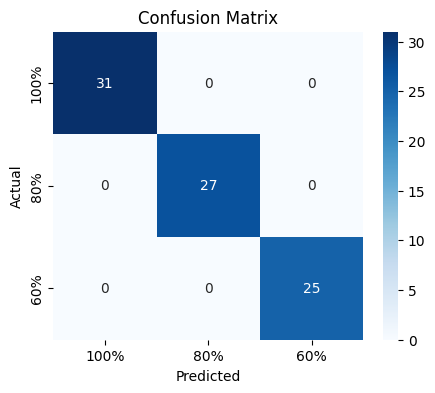

In [107]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# สร้าง confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])

# แสดงผลด้วย heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["100%","80%","60%"], yticklabels=["100%","80%","60%"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


## 7. ตัวอย่างการใช้งาน Inference

โหลดโมเดลที่บันทึกไว้, เตรียมภาพตัวอย่าง แล้วทำนายคลาสเพื่อแสดงการใช้งานจริง


In [99]:
from transformers import AutoImageProcessor, AutoModelForImageClassification
import torch
from PIL import Image

# path ของโมเดลที่คุณ save หลัง fine-tune
model_path = "/kaggle/working/convnext_2class"

# โหลด feature extractor และโมเดล
feature_extractor = AutoImageProcessor.from_pretrained(model_path)
model = AutoModelForImageClassification.from_pretrained(model_path)

# ส่งโมเดลไป GPU ถ้ามี
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()


OSError: Can't load image processor for '/kaggle/working/convnext_2class'. If you were trying to load it from 'https://huggingface.co/models', make sure you don't have a local directory with the same name. Otherwise, make sure '/kaggle/working/convnext_2class' is the correct path to a directory containing a preprocessor_config.json file

In [ ]:
# ตัวอย่างโหลดรูปเดียว
img_path = "/kaggle/input/scscsc/final_dataset_split/test/1/ดี_frame_00015_aug0.jpg"
image = Image.open(img_path).convert("RGB")

# preprocess
inputs = feature_extractor(image, return_tensors="pt").to(device)


In [ ]:
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    predicted_class_idx = logits.argmax(-1).item()  # index ของ class
    predicted_label = model.config.id2label[predicted_class_idx]

print("Predicted class:", predicted_label)
